# Нейросеть для предсказания калорийности блюд

**Описание задачи**

Создать и обучить нейросеть, которая будет предсказывать калорийность блюд. Полученную модель можно интегрировать во многие fitness и health-приложения, она будет полезна тем, кто следит за своим здоровьем. 

## Библиотеки и функции

### Импорт библиотек

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import pandas as pd

from scripts.model import train, predict
from scripts.utils import show_images, show_errors
from scripts.config import Config
    
cfg = Config()

### Функции

In [3]:
def show_info(df: pd.DataFrame) -> None:
    """
    Выводит первичную информацию о датафрейме на экран.
    """
    display(pd.concat([df.head(), df.tail()]))
    df.info()

# 1. EDA

Выполним загрузку файлов `ingredients.csv` и `dish.csv` и выведем на экран первичную информацию.

In [4]:
ingr_df = pd.read_csv(cfg.BASE_DIR / 'data' / 'ingredients.csv').set_index('id')
show_info(ingr_df)

,ingr
id,
1,cottage cheese
2,strawberries
3,garden salad
4,bacon
5,potatoes
551,pizza sauce
552,pomegranate
553,nut cheese
554,soy sausage


<class 'pandas.core.frame.DataFrame'>
Index: 555 entries, 1 to 555
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ingr    555 non-null    object
dtypes: object(1)
memory usage: 8.7+ KB


In [5]:
dish_df = pd.read_csv(cfg.BASE_DIR / 'data' / 'dish.csv').set_index('dish_id')
show_info(dish_df)

,total_calories,total_mass,ingredients,split
dish_id,,,,
dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
dish_1558372433,74.360001,143.0,ingr_0000000453,train
dish_1563295334,228.540009,96.0,ingr_0000000004;ingr_0000000008,train
dish_1566329234,262.625214,457.0,ingr_0000000161;ingr_0000000189;ingr_000000000...,train
dish_1562691737,485.676880,700.0,ingr_0000000543;ingr_0000000027;ingr_000000012...,train
dish_1558458496,53.130001,77.0,ingr_0000000440,train


<class 'pandas.core.frame.DataFrame'>
Index: 3262 entries, dish_1561662216 to dish_1568664931
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total_calories  3262 non-null   float64
 1   total_mass      3262 non-null   float64
 2   ingredients     3262 non-null   object 
 3   split           3262 non-null   object 
dtypes: float64(2), object(2)
memory usage: 127.4+ KB


Данные соответствуют описанию, пропуски отсутствуют.

В данный момент признак `ingredients` в датафрейме `dish_df` имеет вид `ingr_0000000508;ingr_0000000122;...`, заменим идентификаторы на настоящие названия ингредиентов, сделав из датафрейма `ingr_df` словарь вида `id: name`, а затем выполним мэппинг идентификаторов ингредиентов.

In [6]:
id_to_name = ingr_df['ingr'].to_dict()

dish_df['ingredients'] = (
    dish_df['ingredients']
    .str.split(';')
    .apply(lambda lst: [
        id_to_name.get(int(item.split('_')[-1])) 
        for item in lst
    ])
)

dish_df['ingredients'] = dish_df['ingredients'].apply(';'.join)

dish_df

,total_calories,total_mass,ingredients,split
dish_id,,,,
dish_1561662216,300.794281,193.0,soy sauce;garlic;white rice;parsley;onions;bro...,test
dish_1561662054,419.438782,292.0,pepper;white rice;mixed greens;garlic;soy sauc...,train
dish_1562008979,382.936646,290.0,jalapenos;lemon juice;pork;wheat berry;cabbage...,test
dish_1560455030,20.590000,103.0,cherry tomatoes;cucumbers;baby carrots,train
dish_1558372433,74.360001,143.0,deprecated,train
...,...,...,...,...
dish_1563295334,228.540009,96.0,bacon;scrambled eggs,train
dish_1566329234,262.625214,457.0,olive oil;vinegar;cauliflower;bok choy;millet;...,train
dish_1562691737,485.676880,700.0,chia seeds;broccoli;egg whites;yam;chicken app...,train


Видим, что теперь в столбце `ingredients` находятся строки ингредиентов, разделённые знаком `;`.

Построим гистограммы количественных признаков `total_mass` и `total_calories`.

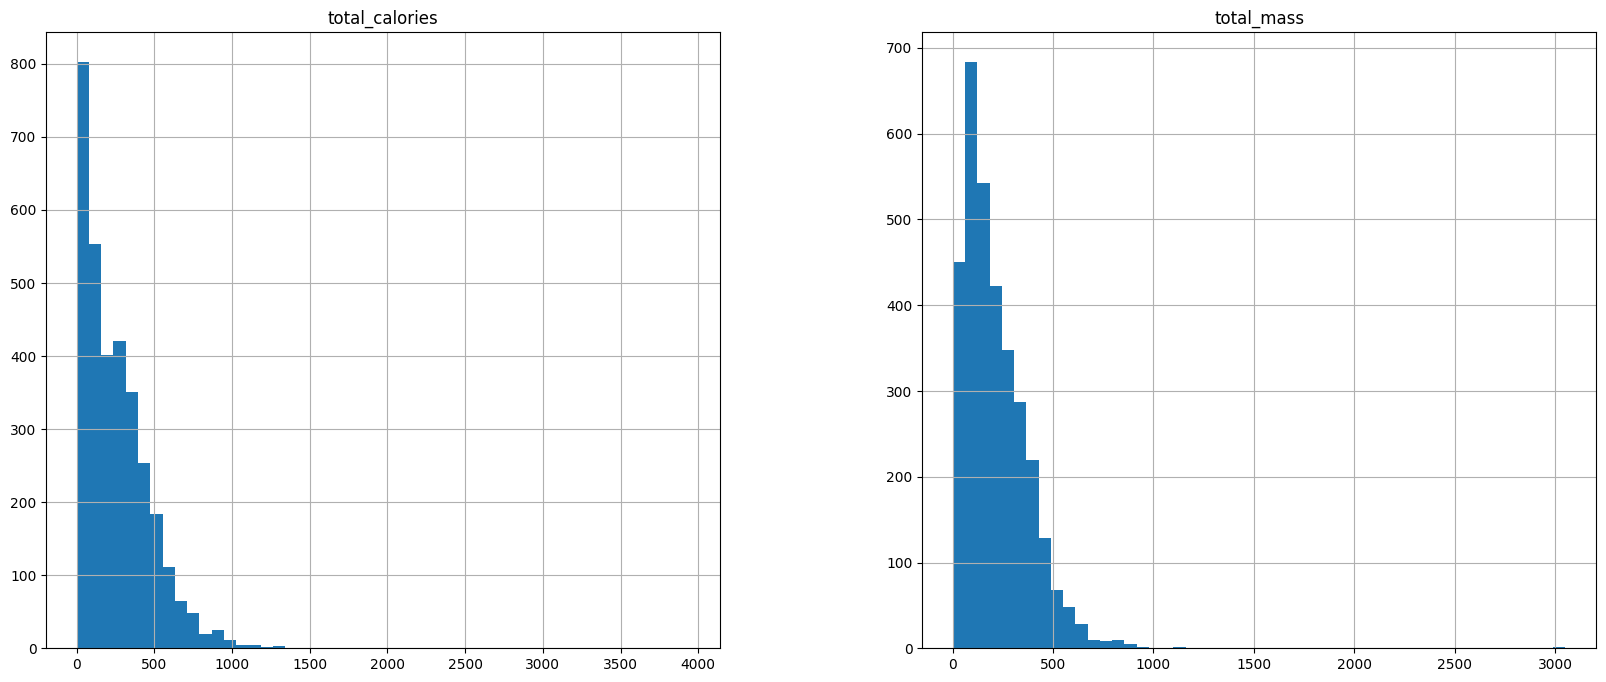

In [7]:
dish_df.hist(figsize=(20, 8), bins=50);

Распределения `total_calories` и `total_mass` имеют выраженную положительную ассиметрию: большинство объектов сосредоточено в области низких и средних значений, а большие значения встречаются значительно реже. Это указывает на дисбаланс данных, при котором модель получает большинство примеров относительно лёгких и низкокалорийных блюд. Поскольку калорийность напрямую связана с массой блюда, подобный дисбаланс может затруднять обучение на редких тяжёлых и высококалорийных объектах, что потенциально может привести к повышенным ошибкам на таких примерах.

Выведем на экран несколько изображений из датасета.

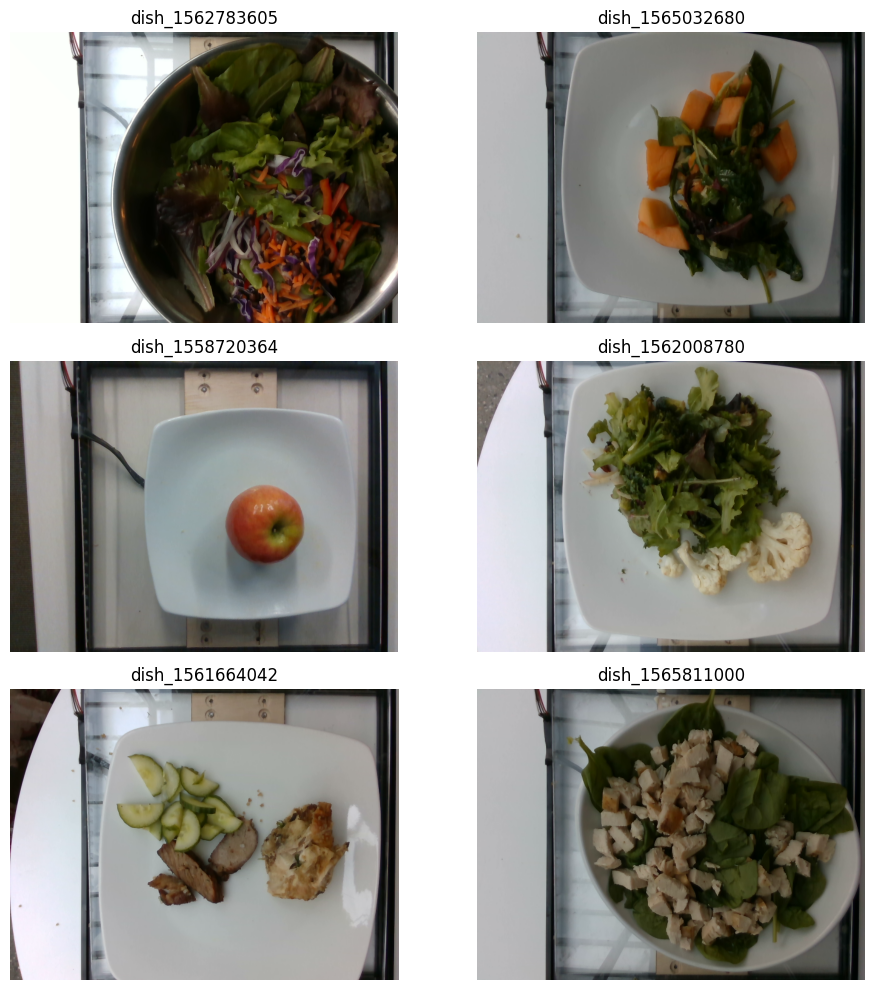

In [8]:
img_path = Path(cfg.IMAGE_DIR)
show_images(dish_df, img_path, 6, cfg)

Можно увидеть, что блюда могут состоять как из одного ингредиента, так и из множества. Можно предположить, что модель будет меньше ошибаться в случае блюд с малым количеством ингредиентов, и больше в случае с большим количеством.

Выполним сохранение получившегося датафрейма в файл `.csv`, чтобы создавать из него датасеты/загрузчики данных.

In [9]:
Path(cfg.PROCESSED_DATA_PATH).parent.mkdir(parents=True, exist_ok=True)

dish_df.to_csv(cfg.PROCESSED_DATA_PATH)

## 2. Обучение модели

Поскольку для каждого объекта доступны сразу несколько типов информации - изображение блюда, список ингредиентов и масса - задача естественным образом формулируется как мультимодальная.

Каждая из модальностей несёт свою часть информации о целевой переменной. Текстовое описание ингредиентов даёт представление о составе блюда: наличие орехов, сыра, масла, бекона и других высококалорийных продуктов уже само по себе может быть сильным сигналом для модели. Однако список ингредиентов не содержит информации о пропорциях компонентов и способе приготовления. Например, один и тот же набор продуктов может соответствовать как лёгкому салату, так и более калорийному блюду с большим количеством масла или соуса.

Изображение, в свою очередь, способно частично компенсировать этот недостаток, предоставляя визуальную информацию о размере порции, соотношении ингредиентов и внешнем виде блюда. При это по одному только изображению оценить калорийность также сложно, поскольку визуально похожие блюда могут существенно отличаться по составу и энергетической ценности.

Дополнительным важным признаком является масса блюда, поскольку калорийность напрямую связана с количеством продукта. Даже при одинаковом составе более тяжёлое блюдо, как правило, будет содержать больше калорий.

С учётом этого была выбрана мультимодальная архитектура, в которой каждая модальность обрабатывается отдельным энкодером:

- **BERT** для текстового описания ингредиентов;
- **EfficientNet** для изображений;
- отдельный линейный слой для числового признака массы.

После извлечения признаков из каждой модальности они приводятся к общему скрытому пространству, объединяются и передаются в регрессионную голову, которая предсказывает итоговую калорийность блюда.

Такой подход выбран как разумный компромисс между качеством и сложность реализации. Более сложные архитектуры с кросс-модальным вниманием потенциально могли бы лучше моделировать взаимодействие между текстом и изображением, однако при относительно небольшом объёме данных это повышает риск переобучения. Поэтому на данном этапе используется более простая и устойчивая схема late fusion, позволяющая эффективно использовать преимущества всех доступных модальностей.

Также предварительные эксперименты показали, что каждая модальность вносит вклад в итоговое качество:
- Использование только текстового описания ингредиентов и массы блюда давало результат ~45 MAE;
- Использование только картинки и массы давало результат ~60 MAE.

Это говорит о том, что хотя текстовые признаки являются наиболее информативными, визуальная модальность также содержит полезный дополнительный сигнал.

Используем написанную функцию `train` из файла `scripts/model.py` для обучения модели.

In [10]:
model = train(cfg)

[Text encoder (BERT)]
Trainable params: 14,766,336 / 109,482,240
Trainable ratio: 13.49%
Unfreeze_patterns: ['encoder.layer.10', 'encoder.layer.11', 'pooler']

[Image encoder (EfficientNet)]
Trainable params: 1,129,392 / 4,007,548
Trainable ratio: 28.18%
Unfreeze_patterns: ['blocks.6', 'conv_head', 'bn2']

Обучение модели...

Epoch 1/40 | Train Loss: 119.2928 | Val Loss: 76.2327 | Val mae: 89.3849
Epoch 2/40 | Train Loss: 54.2433 | Val Loss: 43.5415 | Val mae: 55.6374
Epoch 3/40 | Train Loss: 42.6983 | Val Loss: 63.3564 | Val mae: 76.0095
Epoch 4/40 | Train Loss: 42.1847 | Val Loss: 36.4203 | Val mae: 48.2674
Epoch 5/40 | Train Loss: 35.1892 | Val Loss: 41.9477 | Val mae: 54.1510
Epoch 6/40 | Train Loss: 35.7708 | Val Loss: 32.9174 | Val mae: 44.9081
Epoch 7/40 | Train Loss: 30.3074 | Val Loss: 40.3028 | Val mae: 52.4213
Epoch 8/40 | Train Loss: 30.7769 | Val Loss: 33.0328 | Val mae: 44.8293
Epoch 9/40 | Train Loss: 27.2448 | Val Loss: 31.8196 | Val mae: 43.2791
Epoch 10/40 | Train Los

В процессе обучения модель демонстрировала устойчивое снижение ошибки как на обучающей, так и на валидационной выборках, что говорит о том, что архитектура успешно извлекает полезные закономерности из доступных данных. При этом по мере обучения наблюдались локальные колебания валидационной метрики, что ожидаемо для задачи с относительно небольшим объёмом данных, активными аугментациями и дообучением предобученных энкодеров.

Также заметен некоторый разрыв между обучающей и валидационной ошибками, указывающий на умеренное переобучение, что является типичным поведением для моделей подобной сложности при ограниченном размере датасета. Тем не менее общая динамика валидационных метрик оставалась положительной: несмотря на промежуточные колебания, ошибка на валидационной выборке постепенно снижалась, что говорит о сохранении способности модели к обобщению.

## 3. Инференс

Выполним предсказание, использовав функцию `predict`, которая вернёт датафрейм со всеми предсказаниями и датафреймы с топ-5 максимальных и минимальных ошибок, и построим графики для обоих случаев.

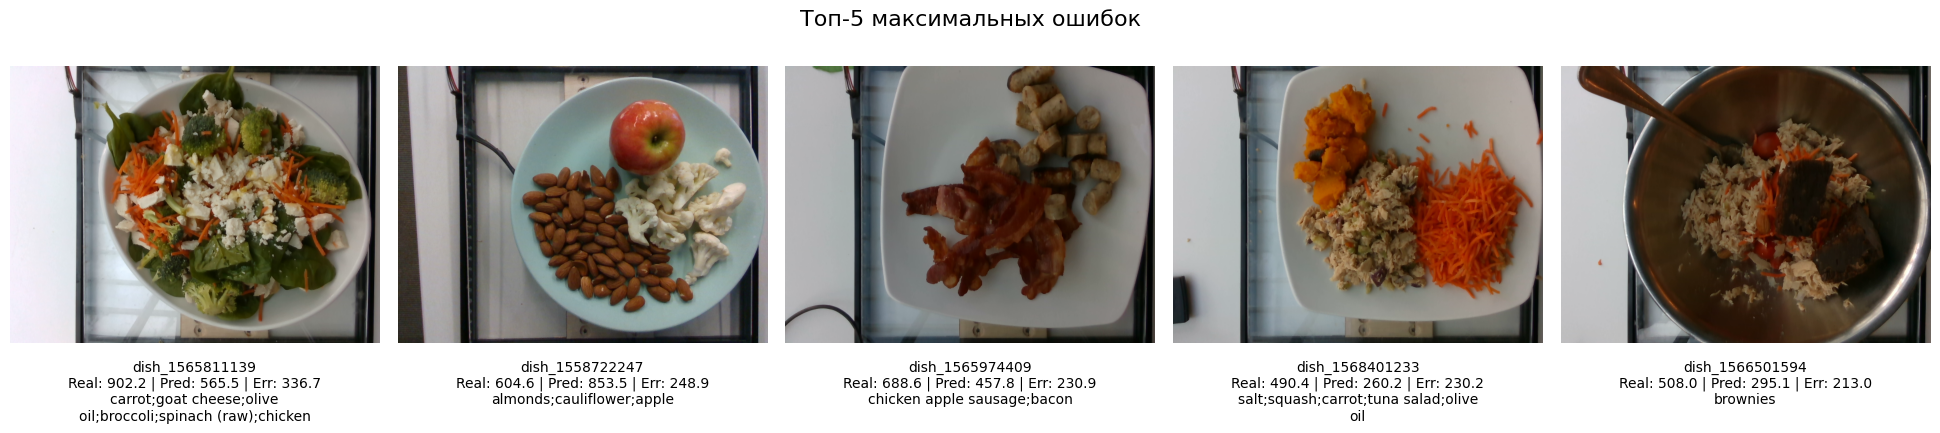

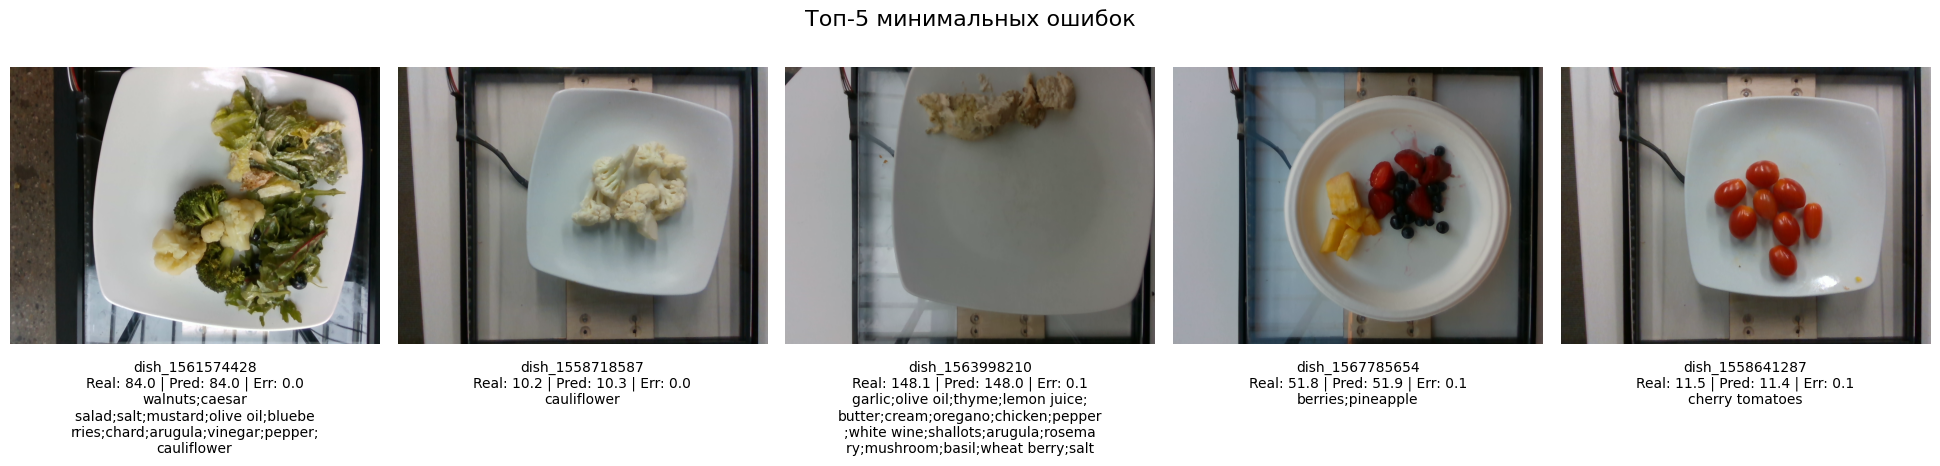

In [11]:
test_pred, top5_largest, top5_smallest = predict(model, cfg)

show_errors(top5_largest, cfg.IMAGE_DIR, 'Топ-5 максимальных ошибок')

show_errors(top5_smallest, cfg.IMAGE_DIR, 'Топ-5 минимальных ошибок')

Анализ примеров с наибольшими и наименьшими ошибками позволяет лучше понять ограничения построенной модели. Наибольшие ошибки наблюдаются преимущественно для блюд с высокой калорийной плотностью, содержащих орехи, сыр, масло, пиццу и другие калорийные ингредиенты. Вероятно, одна из причин заключается в том, что модель не обладает точной информацией о граммовках отдельных компонентов блюда. Хотя список ингредиентов позволяет понять состав, он не отражает количественные соотношения между ними. Например, наличие ингредиента *almonds* говорит модели о присутствии калорийного продукта, но не даёт информации о том, идёт ли речь о небольшой добавке или о полноценной порции орехов, что существенно влияет на итоговую калорийность.

Изображение частично компенсирует этот недостаток, поскольку содержит информацию о внешнем виде блюда, размере порции и визуальных пропорциях компонентов, однако по одному RGB-изображению модели довольно сложно оценить точное количество каждого ингредиента.

При этом среди примеров с минимальной ошибкой заметно, что модель особенно хорошо справляется с блюдами, где состав либо очень простой (например, один доминирующий ингредиент), либо визуальная и текстовая информация однозначно указывают на калорийность блюда. В таких случаях неопределённость существенно ниже, и задача регрессии становится проще.

Таким образом, основное ограничение модели связано не столько с качеством архитектуры, сколько с неполнотой доступной информации: модель пытается оценить калорийность блюда по составу, общему изображению и массе, но не имеет явных данных о точных количествах отдельных ингредиентов. Именно это, вероятно, является одной из ключевых причин ошибок на сложных или высококалорийных блюдах.